Preliminary analysis:
Import the datasets into the Python environment
Examine the dataset's shape and structure, and look out for any outlier
Merge the datasets into a single dataset that includes the date, item id, price, item count, item names, kcal values, store id, and store name


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# for EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:


# for prediction models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping
# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# plt.style.use("fivethirtyeight")
pal = sns.color_palette()
pal_list = list(pal)

# for image study
import torch
import datetime as dt
import os
import tqdm


#### Import Dataset

In [ ]:
items = pd.read_csv('/content/drive/MyDrive/AIML_Capstone/Datasets/Capstone 3/items.csv')
restaurants = pd.read_csv('/content/drive/MyDrive/AIML_Capstone/Datasets/Capstone 3/resturants.csv')
sales = pd.read_csv('/content/drive/MyDrive/AIML_Capstone/Datasets/Capstone 3/sales.csv')

#### Examine the datasets

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ MB


In [ ]:
sales.date = pd.to_datetime(sales.date, format="%Y-%m-%d")

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        109600 non-null  datetime64[ns]
 1   item_id     109600 non-null  int64         
 2   price       109600 non-null  float64       
 3   item_count  109600 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 3.3 MB


In [ ]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


In [ ]:
items

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07
...,...,...,...,...,...
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
97,98,2,Original Sweet Milky Soft Drink,579,5.00
98,99,4,Frozen Tomato Soft Drink,423,5.32


In [ ]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [ ]:
restaurants.head()

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


## Merge data to create a single data with date item id, price, item count, item names, kcal values, store id and store name.


In [ ]:
sales.head(2)

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0


In [ ]:
items.head(2)

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09


In [ ]:
sales.shape

(109600, 4)

In [ ]:
merged_data = pd.merge(sales, items, left_on = "item_id", right_on = "id", how = "left")

In [ ]:
merged_data

,date,item_id,price,item_count,id,store_id,name,kcal,cost
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21
...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
109596,2021-12-31,97,28.65,0.0,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
109597,2021-12-31,98,5.00,0.0,98,2,Original Sweet Milky Soft Drink,579,5.00
109598,2021-12-31,99,5.32,0.0,99,4,Frozen Tomato Soft Drink,423,5.32


In [ ]:
restaurants

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


In [ ]:
merged_data.shape

(109600, 9)

In [ ]:
merged_data.head(2)

,date,item_id,price,item_count,id,store_id,name,kcal,cost
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42


In [ ]:
data = pd.merge(merged_data, restaurants, left_on = 'store_id', right_on = 'id')

In [ ]:
data.head(2)

,date,item_id,price,item_count,id_x,store_id,name_x,kcal,cost,id_y,name_y
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner


In [ ]:
data.shape

(109600, 11)

In [ ]:
(data.item_id == data.id_x).all()

np.True_

In [ ]:
(data.store_id == data.id_y).all()

np.True_

## rename the columns for easier understanding and drop the duplicate columns

In [ ]:
data.rename(columns = {"name_x" : "item_name", "name_y": "restaurant_name"}, inplace = True)

In [ ]:
data.drop(columns = ['id_x', 'id_y', 'cost'], inplace = True)

In [ ]:
data.head(2)

,date,item_id,price,item_count,store_id,item_name,kcal,restaurant_name
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner


In [ ]:
data.shape

(109600, 8)

Exploratory data analysis:
1. Examine the overall date wise sales to understand the pattern
2. Find out how sales fluctuate across different days of the week
3. Look for any noticeable trends in the sales data for different months of the year
4. Examine the sales distribution across different quarters averaged over the years.
5. Identify any noticeable patterns.
Compare the performances of the different restaurants.

6. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.


# Study overall sales date-wise to understand the sales pattern.

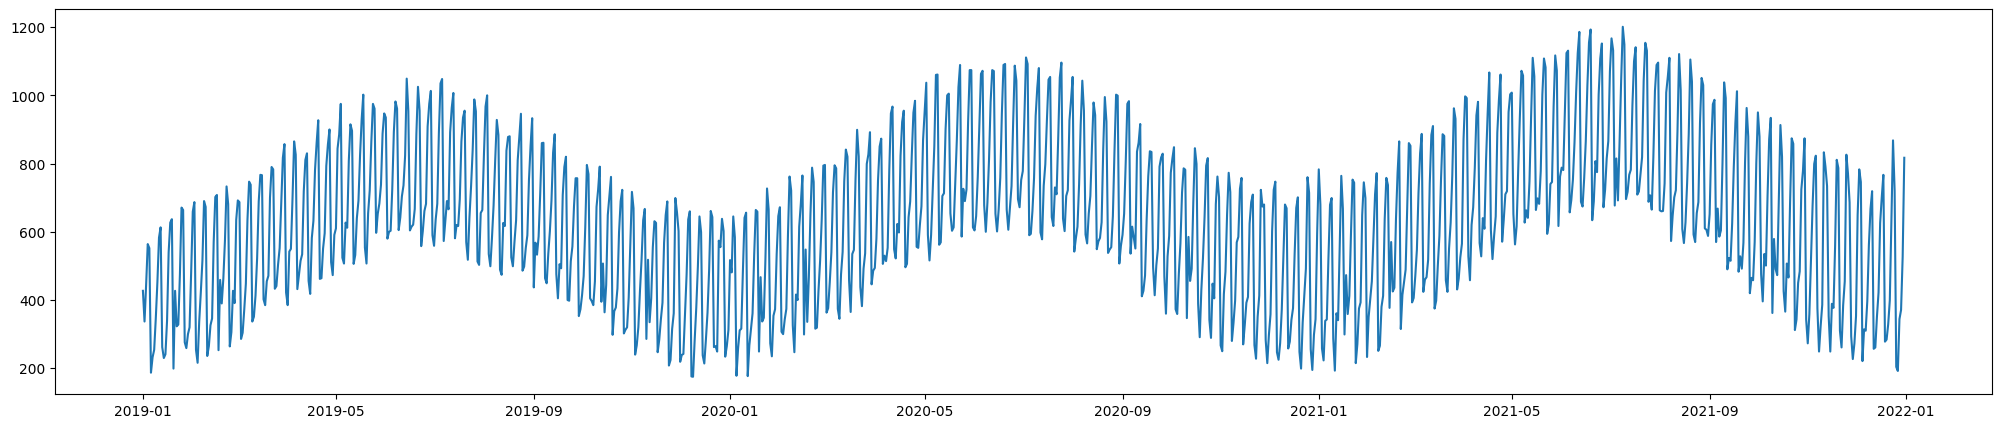

In [ ]:
grpd = sales.groupby(['date'])[['item_count']].sum()
plt.figure(figsize = (25,5))
plt.plot(grpd)
plt.show()

## Find out how the sales fluctuate across different days of the week?

In [ ]:
data['weekday'] = data.date.dt.day_name()

In [1]:
import calendar
day_names = list(calendar.day_name)

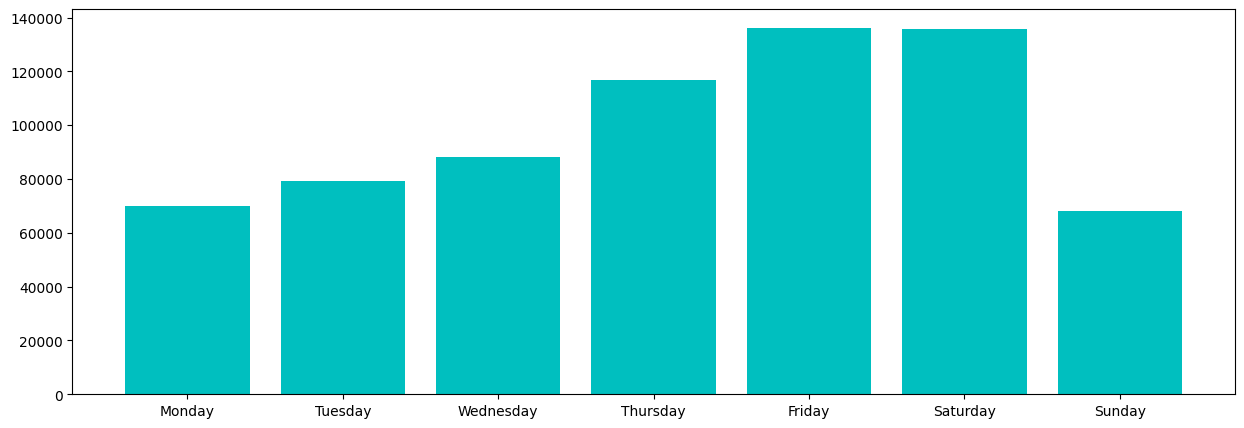

In [ ]:
grpd = data.groupby(['weekday'])[['item_count']].sum()
grpd = grpd.loc[day_names].squeeze()
plt.figure(figsize = (15,5))
plt.bar(height = grpd.values, x = grpd.index, color ='c')
plt.show()

## Look for any noticeable trends in the sales data for different months of the year.

In [ ]:
data['month_name'] = data.date.dt.month_name()

In [3]:
months = list(calendar.month_name)[1:]

In [4]:
months

['January',
 'February',
 'March',
 'April',
 'May',
 'June',
 'July',
 'August',
 'September',
 'October',
 'November',
 'December']

/tmp/ipykernel_11190/1444632008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y= grpd.values, x = grpd.index,palette='viridis')


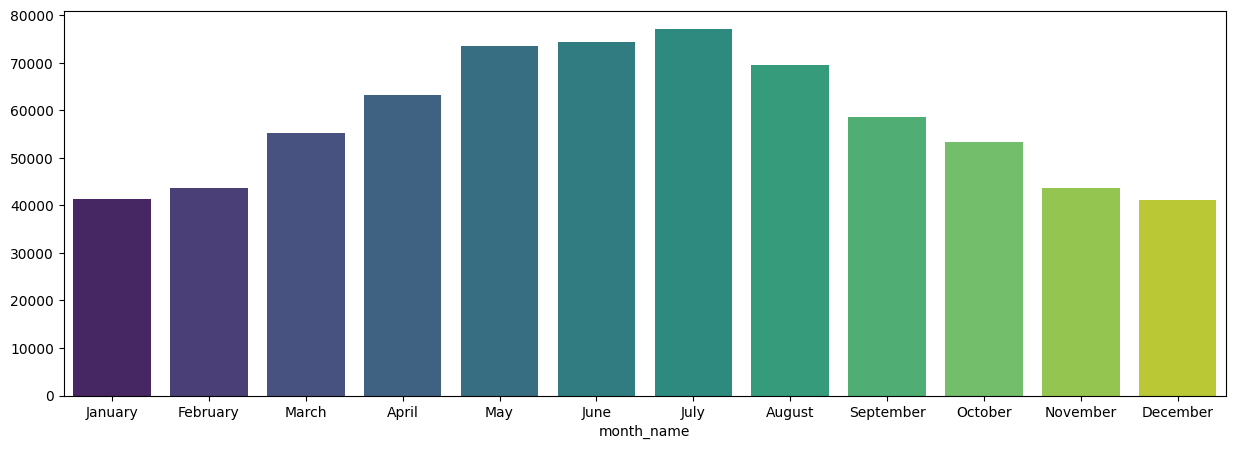

In [ ]:
grpd = data.groupby(['month_name'])[['item_count']].sum()
grpd = grpd.loc[months].squeeze()
plt.figure(figsize = (15,5))
sns.barplot(y= grpd.values, x = grpd.index,palette='viridis')
plt.show()

## Examine the distribution of sales across different quarters averaged over years. Identify any noticeablr pattern in sales.


In [ ]:
data['quarter'] = data.date.dt.quarter

In [ ]:
data

,date,item_id,price,item_count,store_id,item_name,kcal,restaurant_name,weekday,month_name,quarter
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner,Tuesday,January,1
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner,Tuesday,January,1
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,Bob's Diner,Tuesday,January,1
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,Bob's Diner,Tuesday,January,1
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,Bob's Diner,Tuesday,January,1
...,...,...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,5,Blue Ribbon Fish with Bread Lunch,708,Corner Cafe,Friday,December,4
109596,2021-12-31,97,28.65,0.0,4,Original Fruity Cod with Bread and Vegetables ...,744,Fou Cher,Friday,December,4
109597,2021-12-31,98,5.00,0.0,2,Original Sweet Milky Soft Drink,579,Beachfront Bar,Friday,December,4
109598,2021-12-31,99,5.32,0.0,4,Frozen Tomato Soft Drink,423,Fou Cher,Friday,December,4


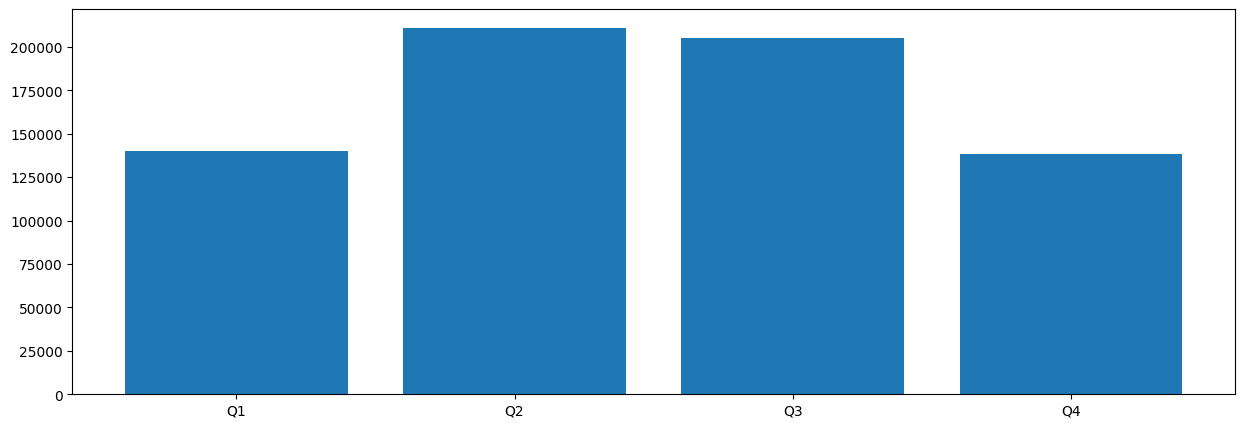

In [ ]:
grpd = data.groupby(['quarter'])[['item_count']].sum().squeeze()
plt.figure(figsize = (15,5))
plt.bar(height = grpd.values, x = grpd.index)
plt.xticks(range(1,5),["Q"+str(i) for i in range(1,5)])
plt.show()

In [ ]:
data['year'] = data.date.dt.year

In [ ]:
data['quart-year'] = "Q" + data.quarter.astype(str) + "-" + data.year.astype(str)

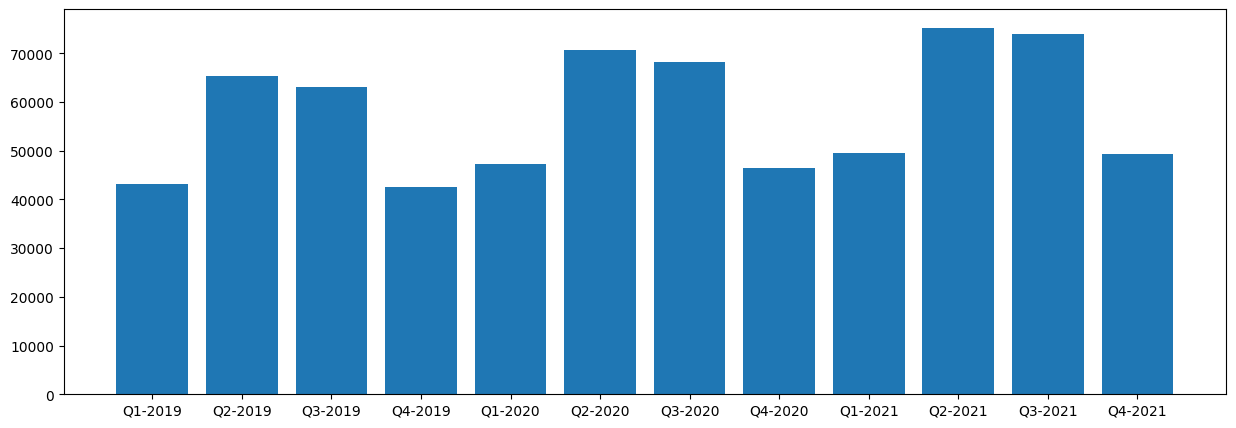

In [ ]:
order = ['Q{}-{}'.format(j,i) for i in range(2019, 2022) for j in range(1,5)]
grpd = data.groupby(["quart-year"])[['item_count']].sum()
grpd = grpd.loc[order].squeeze()
plt.figure(figsize = (15,5))
plt.bar(height = grpd.values, x = grpd.index)
plt.show()

## Compare the performances of different restaurants.Which restaurant had the most sales? Also study the sales for each restaurant across different years months and days.


In [ ]:
data.groupby('store_id')[['item_count']].sum()

,item_count
store_id,
1,687527.0
2,1305.0
3,1736.0
4,1106.0
5,1310.0
6,1803.0


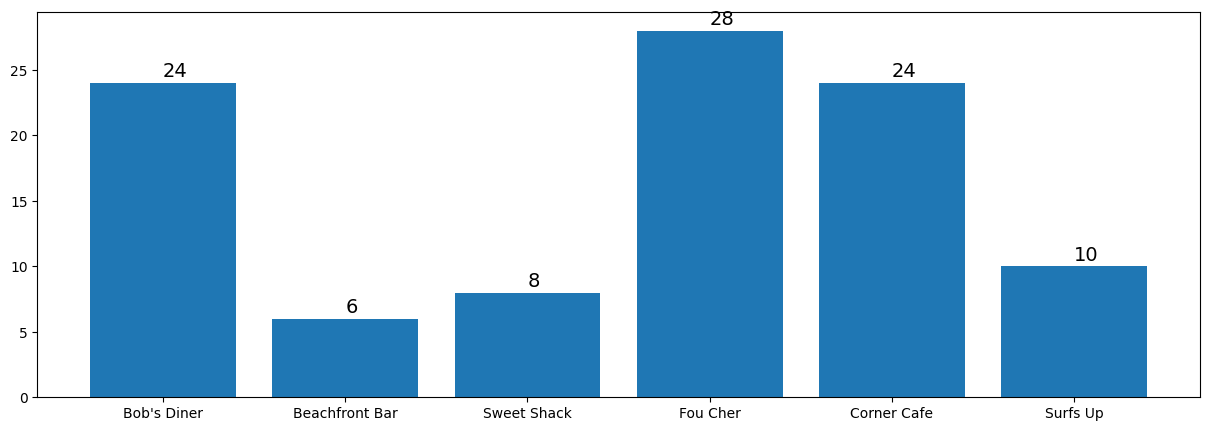

In [ ]:
items_served = items.groupby(['store_id']).agg({'id' : "nunique"}).squeeze()
plt.figure(figsize = (15,5))
plt.bar(items_served.index, items_served.values)
plt.xticks(range(1,7), restaurants.name)
for i in range(1,7):
  plt.annotate(items_served[i], xy = (i, items_served[i]+0.45), size = 14)

plt.show()

## store wise sales

In [ ]:
# plt.style.use("fivethirtyeight")
pal = sns.color_palette()
pal_list = list(pal)

In [ ]:
plot_data = data.pivot_table(index = 'date', columns = 'store_id',values = 'item_count', aggfunc = 'sum')

In [ ]:
plot_data

store_id,1,2,3,4,5,6
date,,,,,,
2019-01-01,421.0,1.0,0.0,1.0,2.0,2.0
2019-01-02,330.0,1.0,1.0,2.0,1.0,2.0
2019-01-03,438.0,1.0,2.0,3.0,0.0,1.0
2019-01-04,559.0,2.0,2.0,1.0,0.0,0.0
2019-01-05,545.0,1.0,2.0,2.0,2.0,0.0
...,...,...,...,...,...,...
2021-12-27,184.0,2.0,2.0,2.0,0.0,2.0
2021-12-28,340.0,1.0,0.0,1.0,0.0,2.0
2021-12-29,366.0,1.0,2.0,0.0,1.0,1.0


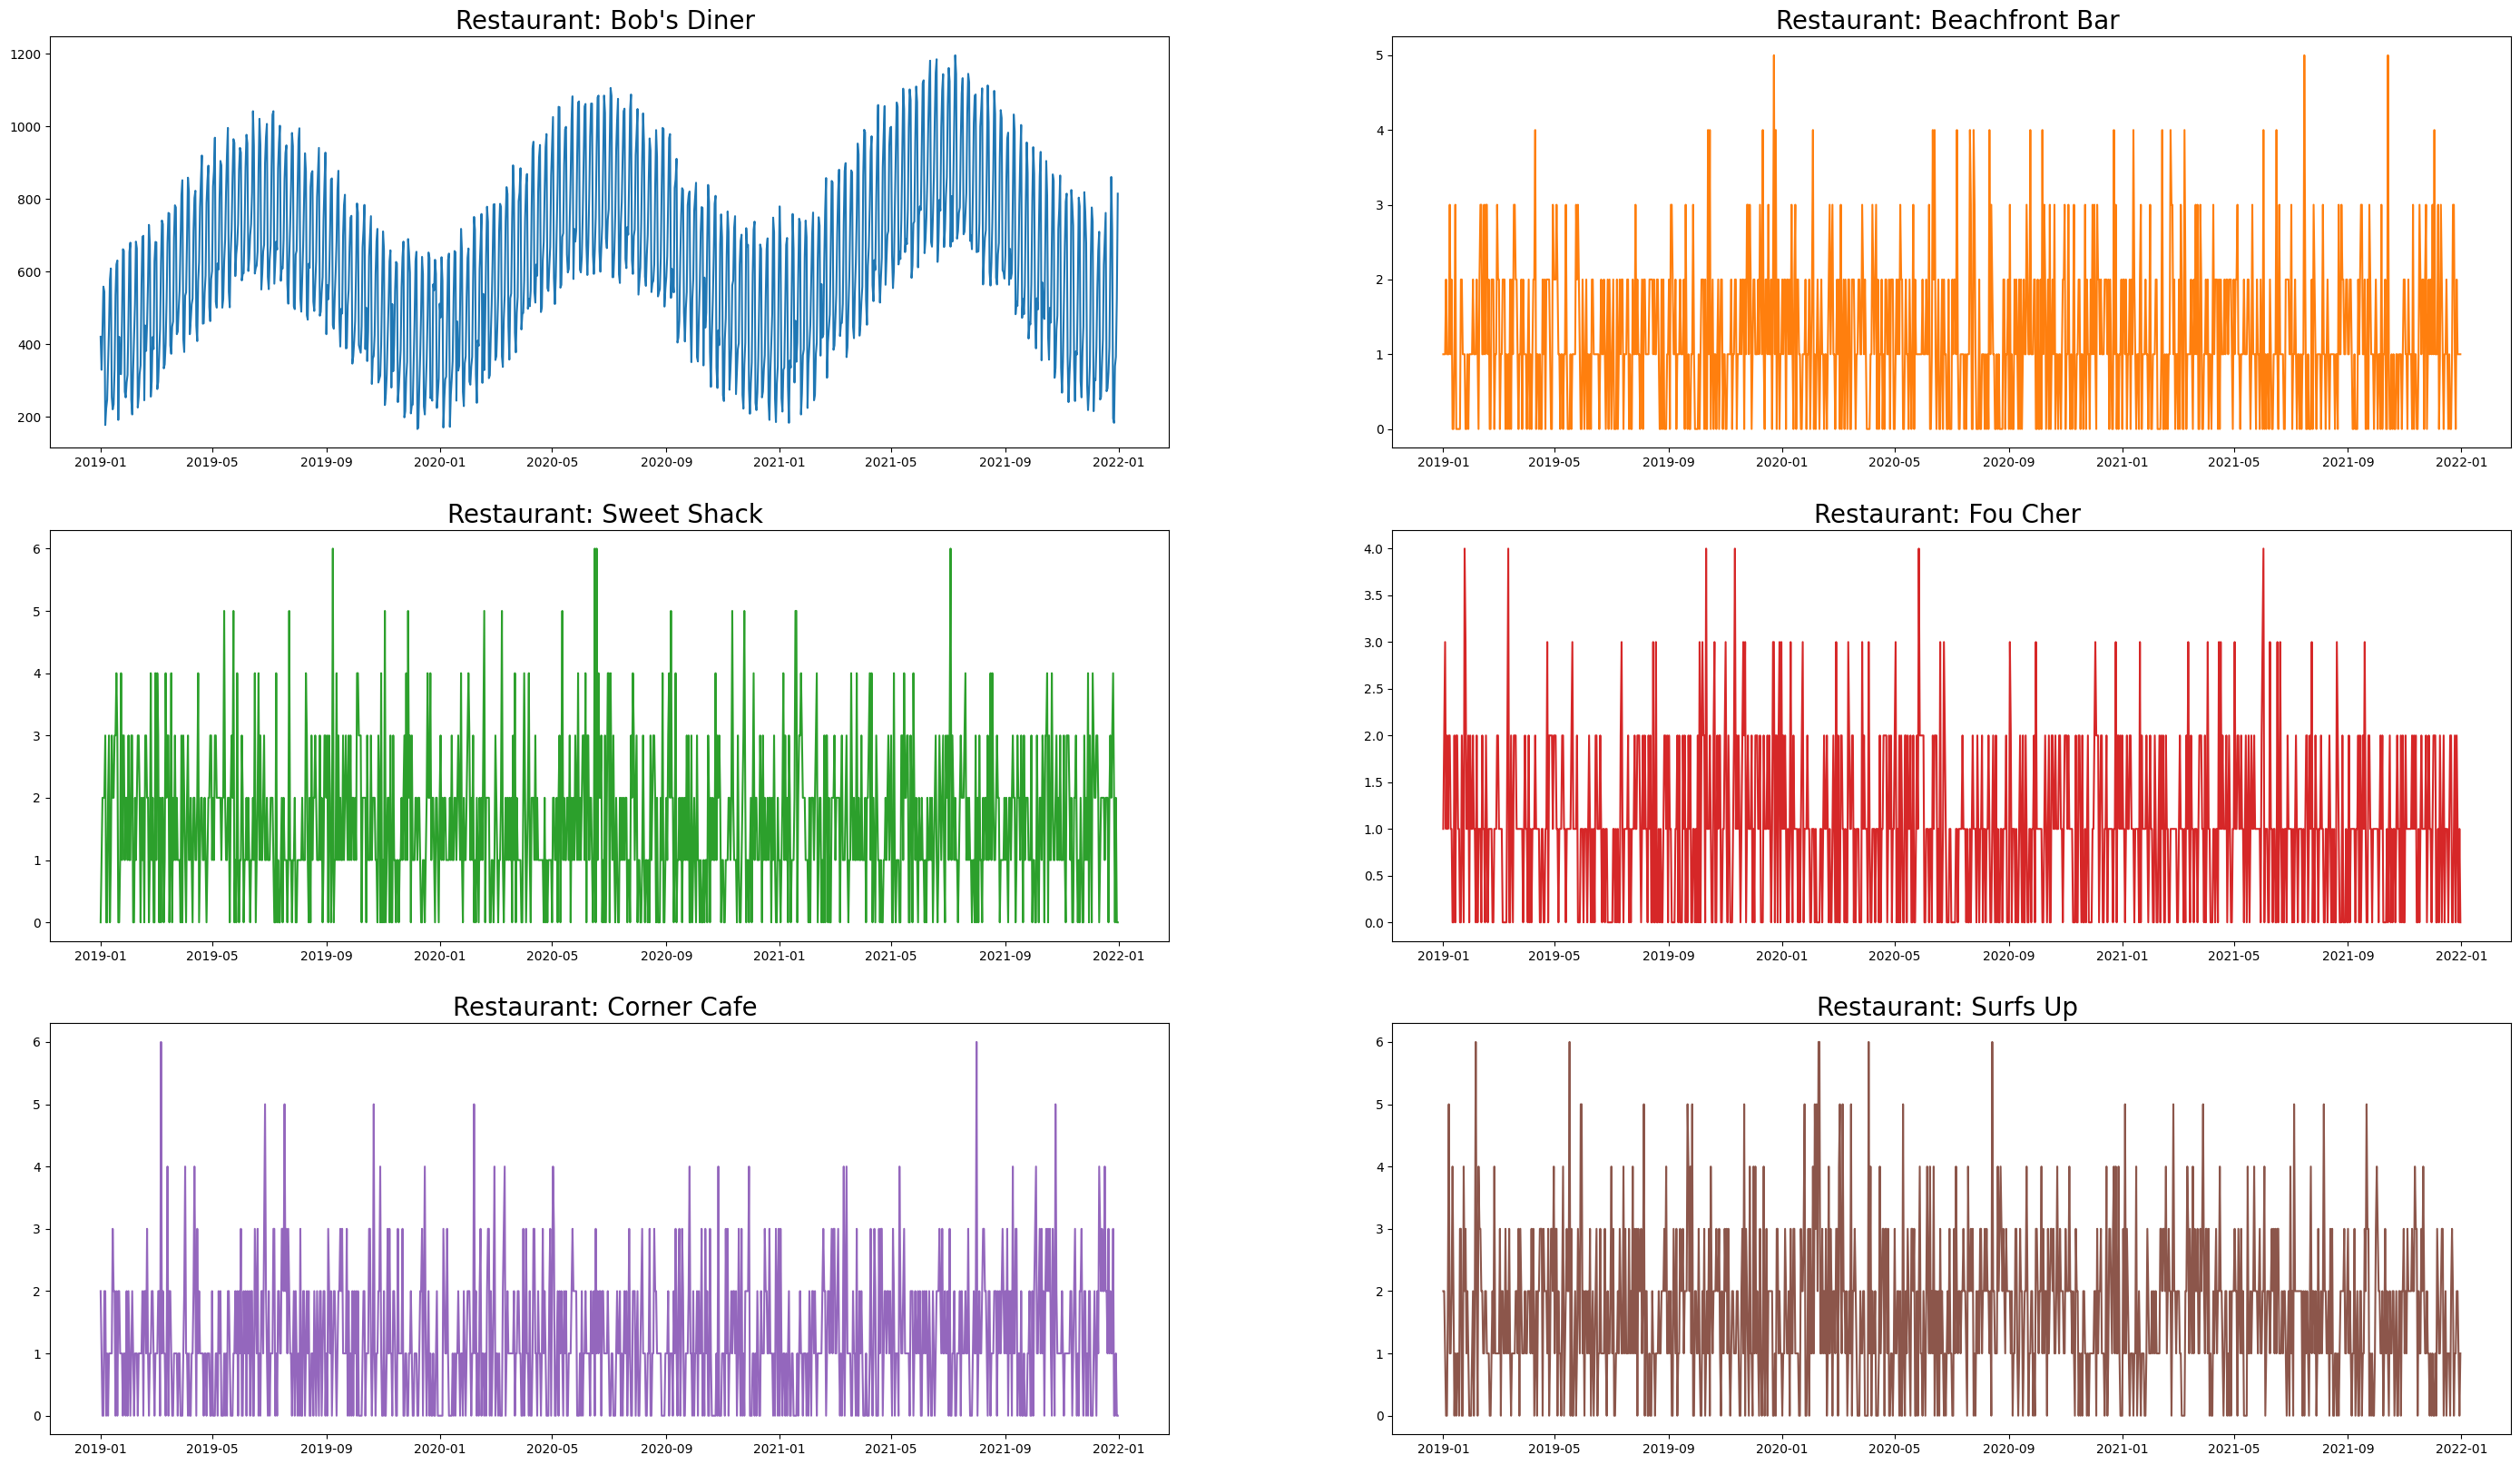

In [ ]:
f,ax = plt.subplots(3,2,figsize =(35,20) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].plot(plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('Restaurant: {} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1


# year wise sales for each store

In [ ]:
plot_data = data.pivot_table(index = 'quart-year', columns = 'store_id',values = 'item_count', aggfunc = 'sum')


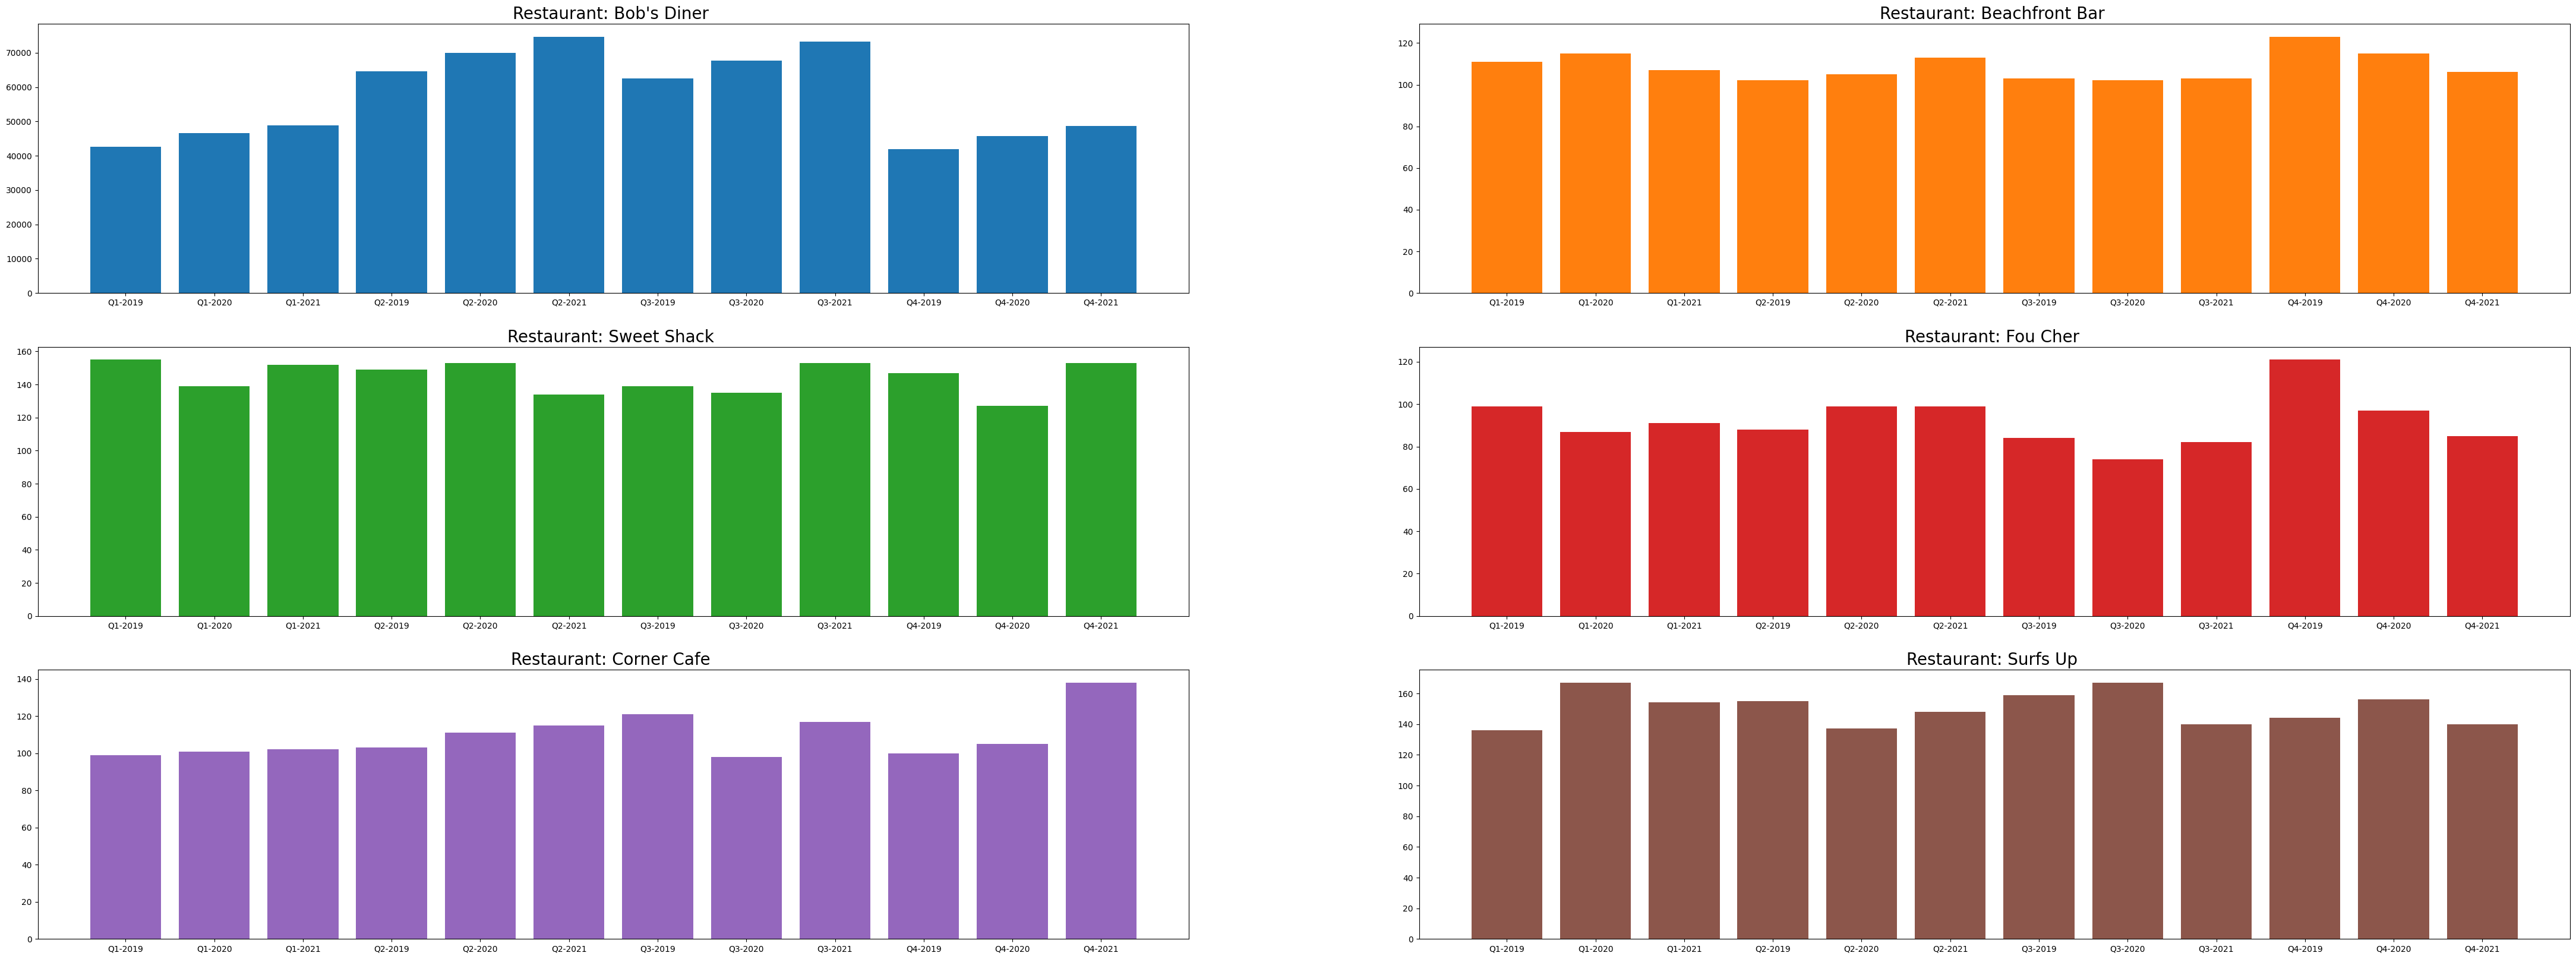

In [ ]:
plot_data = data.pivot_table(index = 'quart-year', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
f,ax = plt.subplots(3,2,figsize =(55,20) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('Restaurant: {} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1


# Month wise sales

/tmp/ipykernel_11190/2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipykernel_11190/2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipykernel_11190/2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipykernel_11190/2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipykernel_11190/2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed num

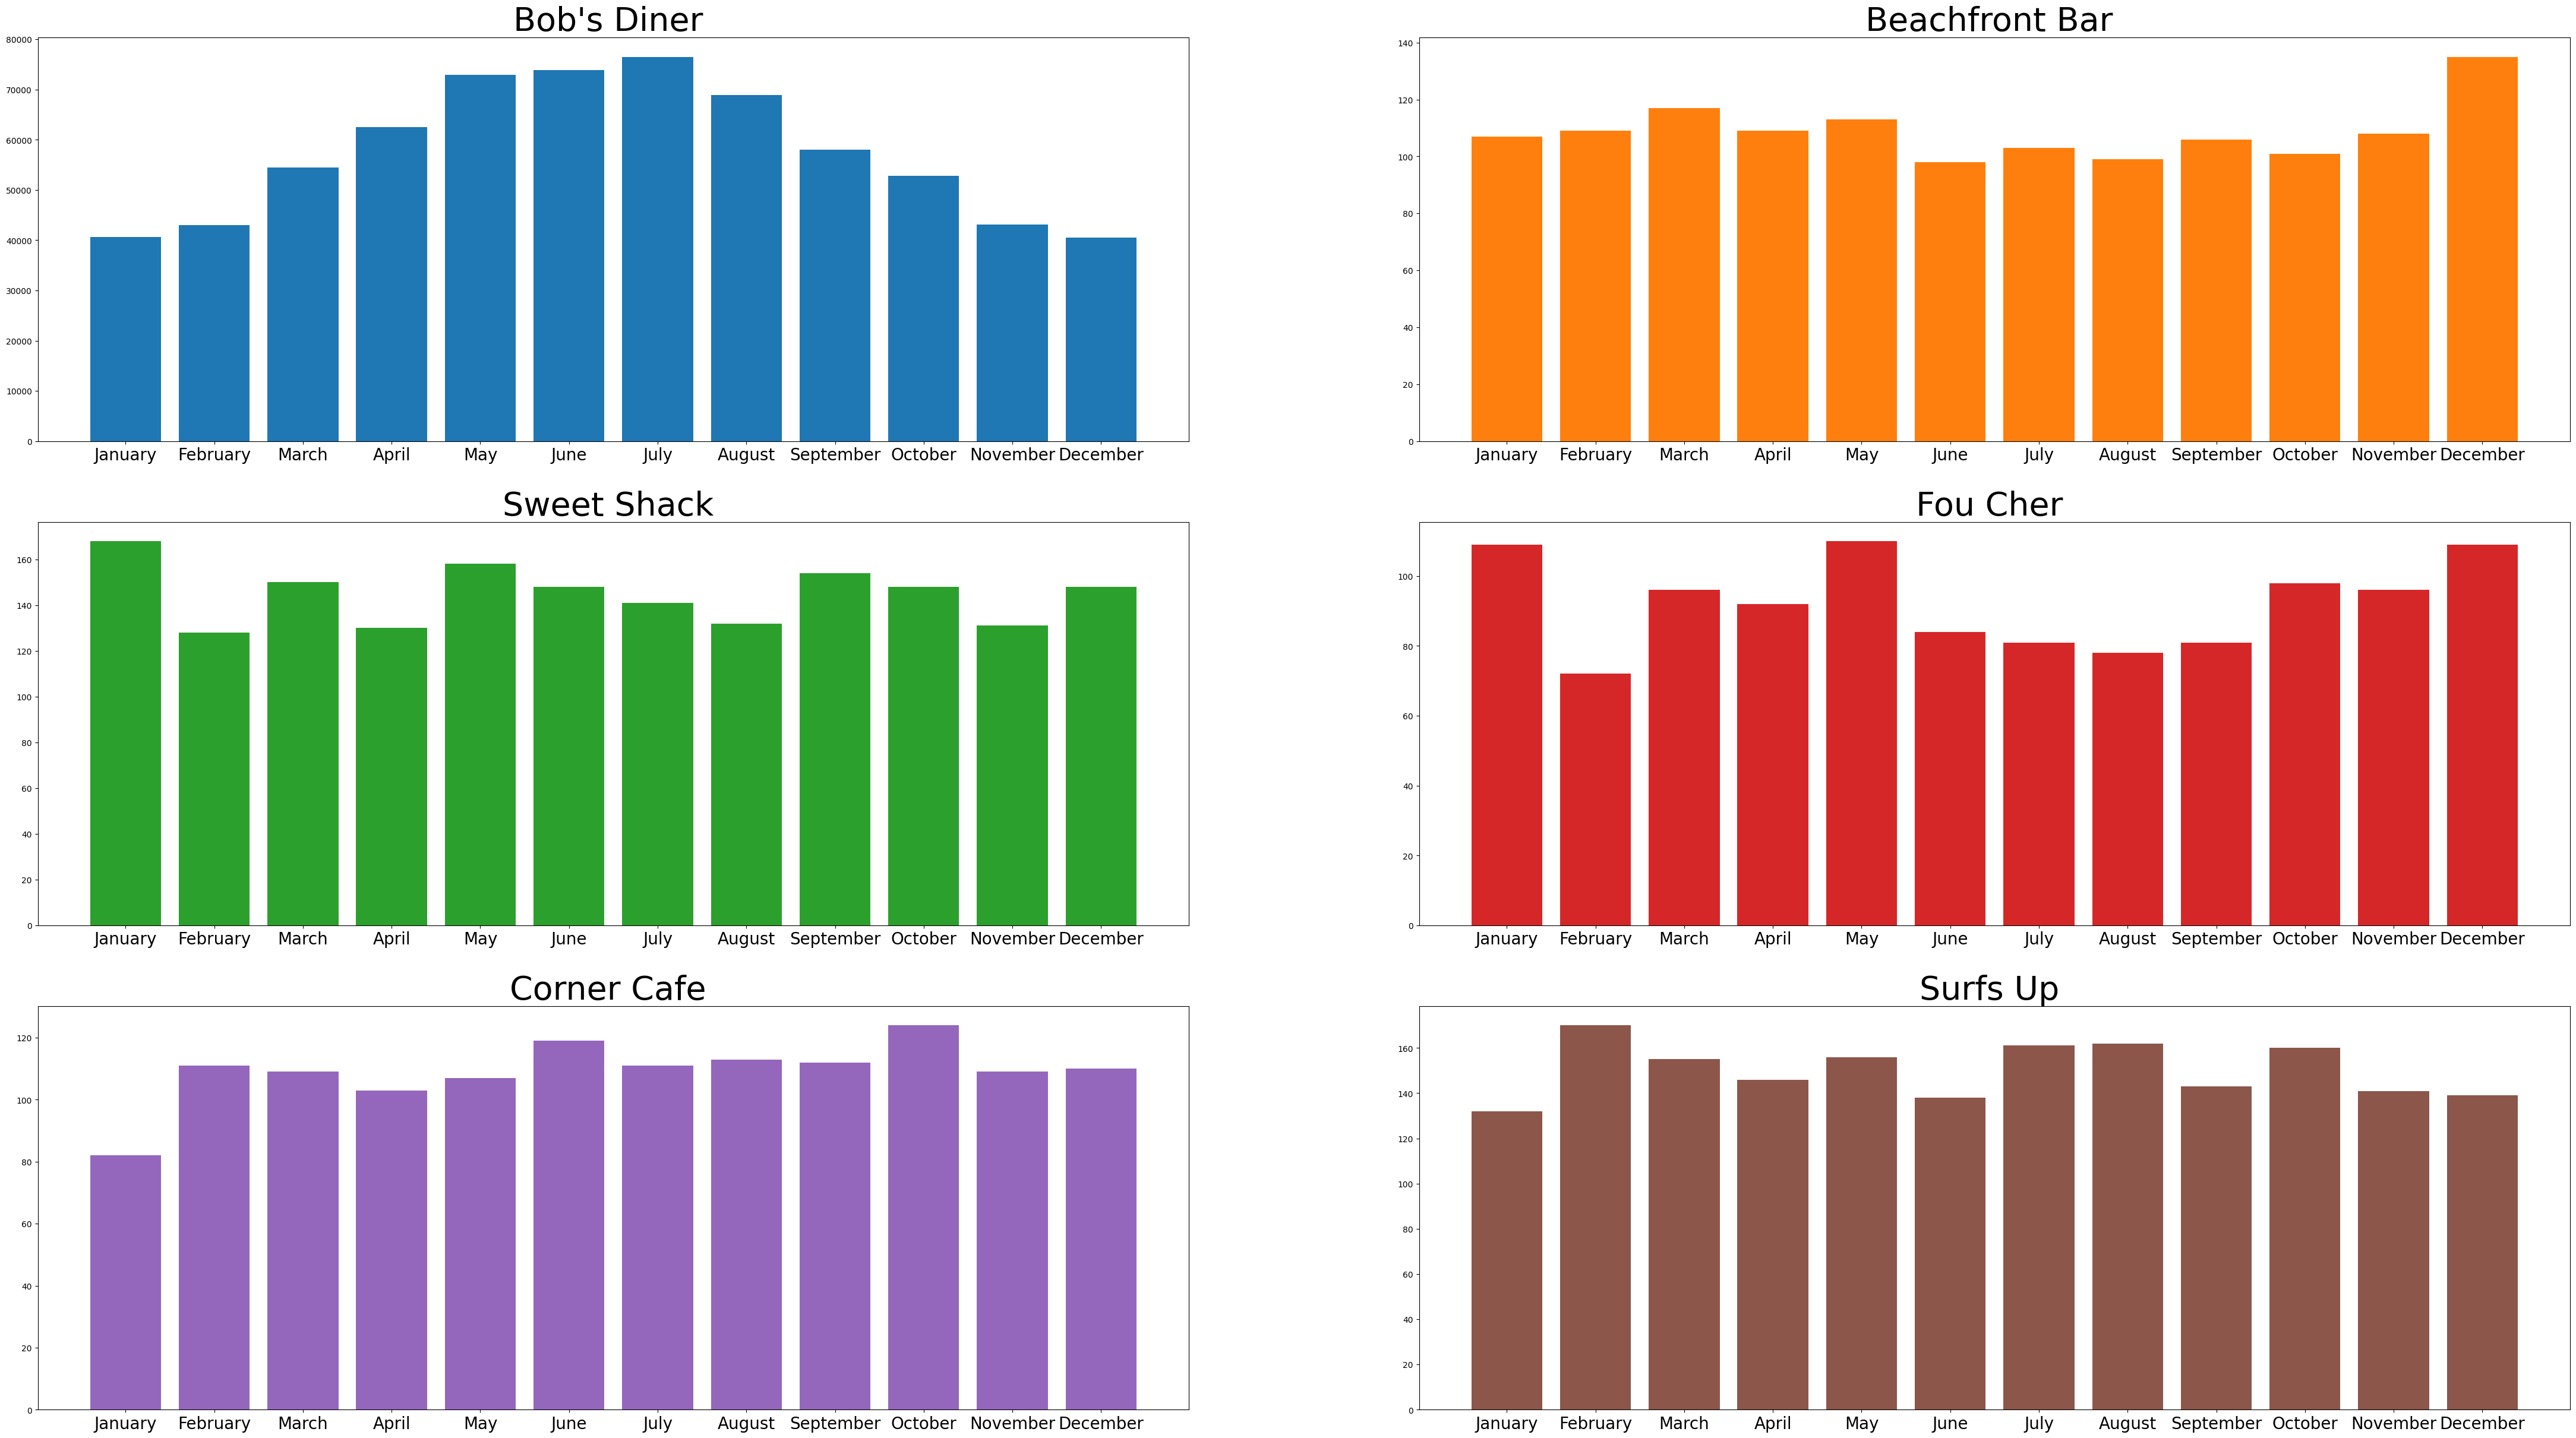

In [ ]:
plot_data = data.pivot_table(index = 'month_name', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = plot_data.loc[months]
f,ax = plt.subplots(3,2,figsize =(55,30) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('{} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 40)
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

# Day wise sales

/tmp/ipykernel_11190/3239954549.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
/tmp/ipykernel_11190/3239954549.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
/tmp/ipykernel_11190/3239954549.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
/tmp/ipykernel_11190/3239954549.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
/tmp/ipykernel_11190/3239954549.py:8: UserWarning: set_ticklabels() should only be used with

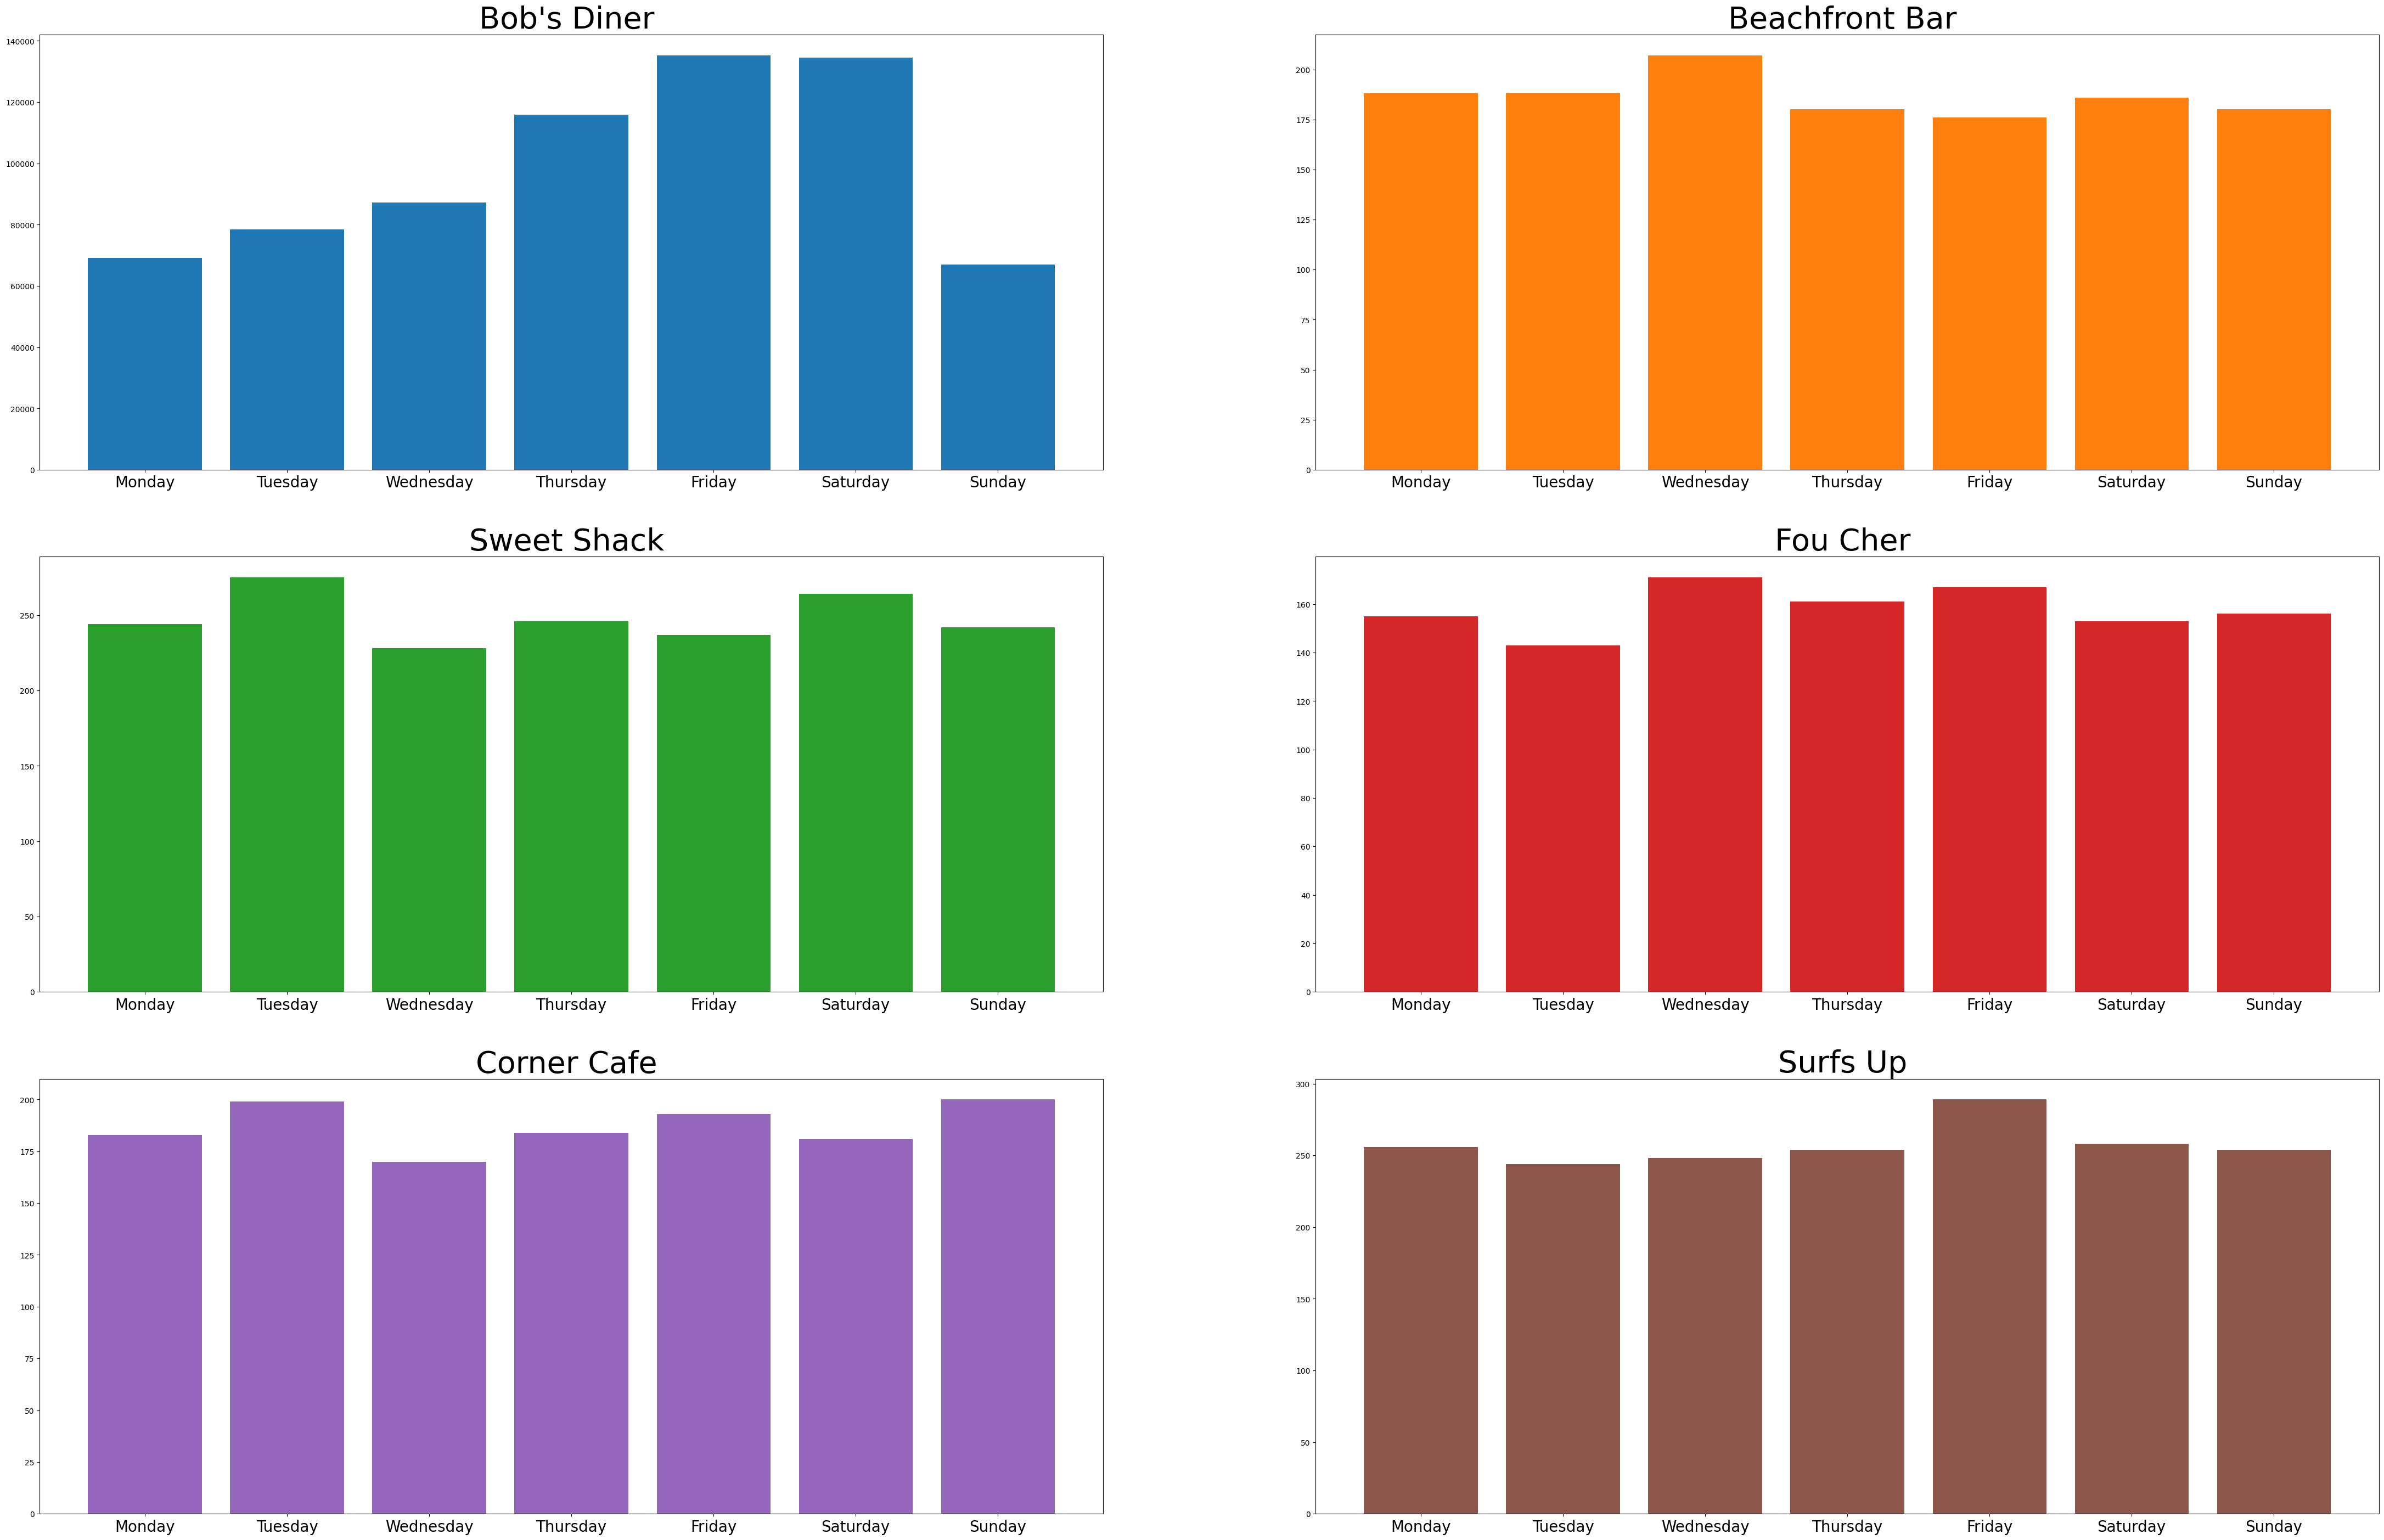

In [ ]:
plot_data = data.pivot_table(index = 'weekday', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = plot_data.loc[day_names]
f,ax = plt.subplots(3,2,figsize =(55,35) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('{} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 40)
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1
plt.show()

# Identify the most popular items overall and the stores where they are being sold. Also find out the most popular item at the store.


In [ ]:
plot_data = data.groupby('item_id')[['item_count']].sum().sort_values('item_count',ascending = False).reset_index()[:5]

In [ ]:
plot_data

,item_id,item_count
0,19,236337.0
1,16,102990.0
2,76,61043.0
3,38,52772.0
4,9,43874.0


In [ ]:
final_plot_data = pd.merge(plot_data, items, left_on = 'item_id', right_on = 'id', how = 'left')[['item_id', 'item_count', 'name', 'kcal', 'cost', 'store_id']]

In [ ]:
final_plot_data

,item_id,item_count,name,kcal,cost,store_id
0,19,236337.0,Strawberry Smoothy,145,2.89,1
1,16,102990.0,Frozen Milky Smoothy,284,3.21,1
2,76,61043.0,Amazing pork lunch,679,17.93,1
3,38,52772.0,Mutton Dinner,542,10.80,1
4,9,43874.0,Orange Juice,135,3.91,1


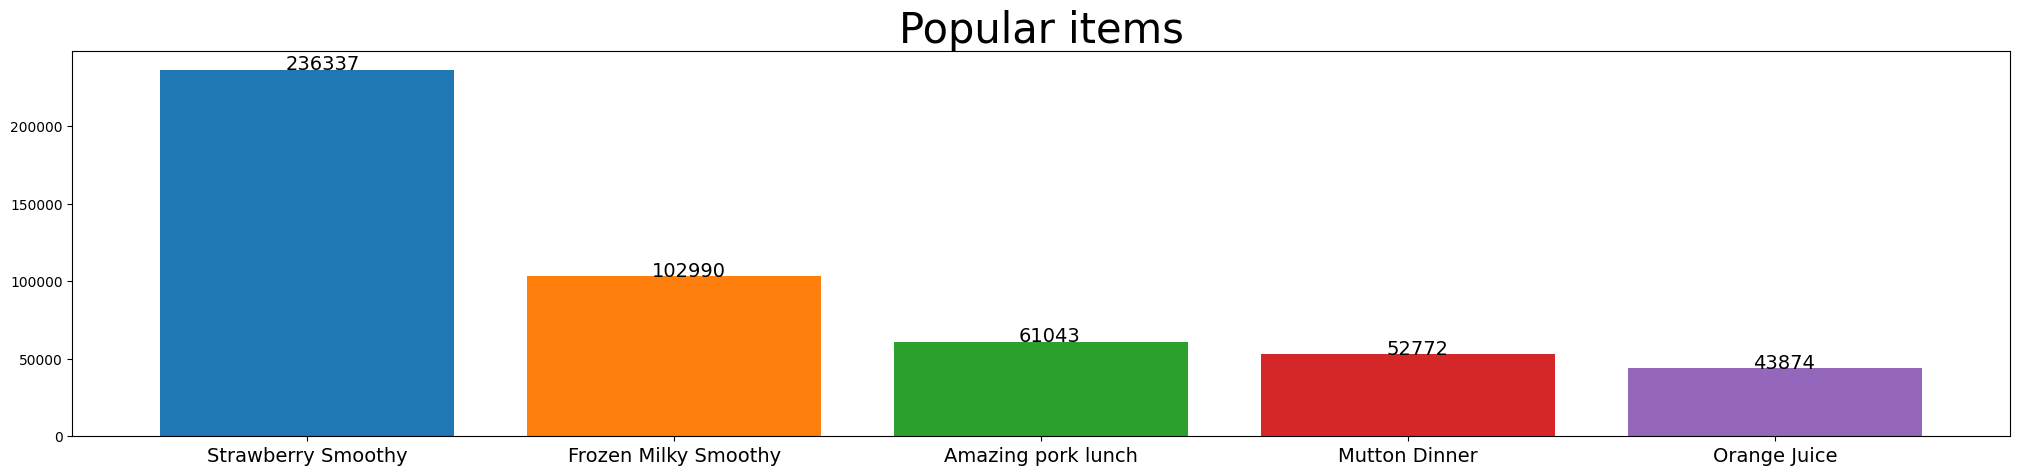

In [ ]:
final_plot_data = pd.merge(plot_data, items, left_on = 'item_id', right_on = 'id', how = 'left')[['item_id', 'item_count', 'name', 'kcal', 'cost', 'store_id']]
plt.figure(figsize = (25,5))
plt.bar(final_plot_data.name, final_plot_data.item_count, color = pal_list)
plt.title('Popular items', size= 30)
for k in range(5):
  val = final_plot_data.loc[k,'item_count']
  plt.annotate('{:0.0f}'.format(val), xy = (k-0.06, val), size = 14)
plt.xticks(size = 14)
plt.show()

In [ ]:
count_data = data.pivot_table(index = 'item_id', columns = 'store_id',values = 'item_count', aggfunc = 'sum', fill_value = 0 )
item_ids = count_data.index[count_data.values.argmax(axis = 0)]


## Popular items restaurant wise

In [ ]:
pop_items = items.loc[items.id.isin(item_ids), ['store_id', 'id', 'name', 'kcal', 'cost']]
pop_data = pd.merge(pop_items, restaurants, how = 'left', left_on = 'store_id', right_on = 'id', suffixes = ('_item', '_restaurant'))
pop_data['count'] = count_data.loc[item_ids,].sum(axis = 0).reset_index().iloc[:,1]
pop_data = pop_data[['name_restaurant', 'name_item', 'kcal', 'cost', 'count']]
pop_data

,name_restaurant,name_item,kcal,cost,count
0,Bob's Diner,Strawberry Smoothy,145,2.89,236337.0
1,Beachfront Bar,Fantastic Milky Smoothy,318,2.91,1147.0
2,Sweet Shack,Awesome Smoothy,78,1.39,1692.0
3,Corner Cafe,Frozen Milky Smoothy,211,3.98,298.0
4,Fou Cher,Blue Ribbon Fruity Vegi Lunch,881,53.98,273.0
5,Surfs Up,Awesome Soft Drink,248,3.06,997.0


# Determine if the store with the highest sales volume is also making the most money per day.


In [ ]:
data.groupby('store_id')[['item_count']].sum().reset_index()

,store_id,item_count
0,1,687527.0
1,2,1305.0
2,3,1736.0
3,4,1106.0
4,5,1310.0
5,6,1803.0


In [ ]:
data.pivot_table(index = 'store_id', columns = 'year', values = 'item_count', aggfunc = 'sum')

year,2019,2020,2021
store_id,,,
1,211799.0,230191.0,245537.0
2,439.0,437.0,429.0
3,590.0,554.0,592.0
4,392.0,357.0,357.0
5,423.0,415.0,472.0
6,594.0,627.0,582.0


In [ ]:
data['sales_amnt'] = data.item_count * data.price

In [ ]:
data.pivot_table(index = 'store_id', columns = 'year', values = 'sales_amnt', aggfunc = 'sum')

year,2019,2020,2021
store_id,,,
1,1849483.49,2112331.91,2375460.29
2,1281.85,1267.21,1247.14
3,872.59,828.65,877.03
4,9698.80,8590.87,9595.70
5,5292.93,5347.71,5910.79
6,5132.65,5314.43,5204.41


In [ ]:
count_order = data.pivot_table(index = 'store_id',  values = 'sales_amnt', aggfunc = 'sum').squeeze()
count_order_rest = count_order.sort_values(ascending = False).index

In [ ]:
count_order_rest

Index([1, 4, 5, 6, 2, 3], dtype='int64', name='store_id')

In [ ]:
sales_order = data.pivot_table(index = 'store_id',  values = 'item_count', aggfunc = 'sum').squeeze()
sales_order_rest = sales_order.sort_values(ascending = False).index

In [ ]:
sales_order_rest

Index([1, 6, 3, 5, 2, 4], dtype='int64', name='store_id')

In [ ]:
restaurants

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


## since restaurant id 1 i.e Bob's Diner has disproportionate data we will leave it out for this analysis to understand that number and sales values match or not for others or not

In [ ]:
count_order

,sales_amnt
store_id,
1,6337275.69
2,3796.20
3,2578.27
4,27885.37
5,16551.43
6,15651.49


In [ ]:
restaurants.set_index('id').loc[count_order_rest]

,name
store_id,
1,Bob's Diner
4,Fou Cher
5,Corner Cafe
6,Surfs Up
2,Beachfront Bar
3,Sweet Shack


In [ ]:
restaurants.set_index('id').loc[sales_order_rest]

,name
store_id,
1,Bob's Diner
6,Surfs Up
3,Sweet Shack
5,Corner Cafe
2,Beachfront Bar
4,Fou Cher


## Bob's Diner is highest grossing in numbers as well as sales value.
## However Fou Cher which is second highest with respect to numbers on the other hand its making least money out of the 6 restaurants

# Identify the most expensive item at each restaurant and find out its calorie count.

In [ ]:
items.iloc[[items.cost.argmax()]]

,id,store_id,name,kcal,cost
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98


In [ ]:
items.sort_values("cost",ascending = False)[:5]

,id,store_id,name,kcal,cost
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98
2,3,1,Sweet Fruity Cake,931,29.22
55,56,1,Sea Bass with Vegetables Dinner,613,28.75
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
33,34,4,Sweet Savory Cake,721,27.47


##  max and min cost of items sold at each restaurant

In [ ]:
items.groupby('store_id')[['cost']].agg(['max', 'min', 'mean'])

cost                 
            max   min       mean
store_id                        
1         29.22  2.89  12.211667
2          5.70  2.43   3.585000
3          7.70  1.39   5.276250
4         53.98  3.23  12.819643
5         26.37  3.74  13.371667
6         26.21  3.06  13.970000

Forecasting using machine learning algorithms:
Build and compare linear regression, random forest, and XGBoost models for predictions
Generate necessary features for the development of these models, like day of the week, quarter of the year, month, year, day of the month and so on
Use the data from the last six months as the testing data
Compute the root mean square error (RMSE) values for each model to compare their performances
Use the best-performing models to make a forecast for the next year


## Develop a linear regression, random forest and XGBoost model to predict for the model with the given data. Compare and comment on the results obtained.
- Create required features for development of these models like day of the week, quarter of the year, month, year, day of the month etc.
- Use the last six months data as test data.
- Compute the RMSE values for each of the models to compare their performances.
- Also use these models to forecast for 1 year.


In [ ]:
data.date.describe()

,date
count,109600
mean,2020-07-01 12:00:00
min,2019-01-01 00:00:00
25%,2019-10-01 18:00:00
50%,2020-07-01 12:00:00
75%,2021-04-01 06:00:00
max,2021-12-31 00:00:00


In [ ]:
ts = data.groupby('date')[['item_count']].sum().squeeze()


In [ ]:
data.head()

,date,item_id,price,item_count,store_id,item_name,kcal,restaurant_name,weekday,month_name,quarter,year,quart-year,sales_amnt
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner,Tuesday,January,1,2019,Q1-2019,58.44
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner,Tuesday,January,1,2019,Q1-2019,581.24
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,Bob's Diner,Tuesday,January,1,2019,Q1-2019,34.09
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,Bob's Diner,Tuesday,January,1,2019,Q1-2019,50.16
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,Bob's Diner,Tuesday,January,1,2019,Q1-2019,436.56


In [ ]:
time_series = data.groupby(['date']).agg({'item_count':'sum', 'weekday': lambda x :x.unique()[0],
                            'quarter' : lambda x :x.unique()[0], 'year': lambda x :x.unique()[0],
                            'month_name' : lambda x :x.unique()[0],
                            'year':lambda x :x.unique()[0]})

# adding some more features : day of the year, day of the month and week of the year

In [ ]:
time_series['day_year'] = time_series.index.day_of_year
time_series['day_month'] = time_series.index.day
time_series['week_num'] = time_series.index.isocalendar().week.astype(int)
time_series

,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427.0,Tuesday,1,2019,January,1,1,1
2019-01-02,337.0,Wednesday,1,2019,January,2,2,1
2019-01-03,445.0,Thursday,1,2019,January,3,3,1
2019-01-04,564.0,Friday,1,2019,January,4,4,1
2019-01-05,552.0,Saturday,1,2019,January,5,5,1
...,...,...,...,...,...,...,...,...
2021-12-27,192.0,Monday,4,2021,December,361,27,52
2021-12-28,344.0,Tuesday,4,2021,December,362,28,52
2021-12-29,371.0,Wednesday,4,2021,December,363,29,52


## convert the categorical to numeric using ordinal encoder as here data is ordered in terms of weekday and month name

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [2]:
day_names

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [ ]:
ord_enc = OrdinalEncoder(categories = [months, day_names])
ord_enc.fit(time_series[['month_name', 'weekday']])
time_series[['month_name', 'weekday']] = ord_enc.transform(time_series[['month_name', 'weekday']])

In [ ]:
time_series

,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427.0,1.0,1,2019,0.0,1,1,1
2019-01-02,337.0,2.0,1,2019,0.0,2,2,1
2019-01-03,445.0,3.0,1,2019,0.0,3,3,1
2019-01-04,564.0,4.0,1,2019,0.0,4,4,1
2019-01-05,552.0,5.0,1,2019,0.0,5,5,1
...,...,...,...,...,...,...,...,...
2021-12-27,192.0,0.0,4,2021,11.0,361,27,52
2021-12-28,344.0,1.0,4,2021,11.0,362,28,52
2021-12-29,371.0,2.0,4,2021,11.0,363,29,52


## Generate Test Data

In [ ]:
train = time_series[time_series.index < '2021-07-01']
test = time_series[time_series.index >= '2021-07-01']

In [ ]:
y_var = 'item_count'
x_vars = time_series.drop(columns = 'item_count').columns

In [ ]:
X_train = train[x_vars]
Y_train = train[y_var]
X_test = test[x_vars]
Y_test = test[y_var]

## Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

In [ ]:
test['lr_pred'] = lr.predict(X_test)

/tmp/ipykernel_11190/3421247276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['lr_pred'] = lr.predict(X_test)


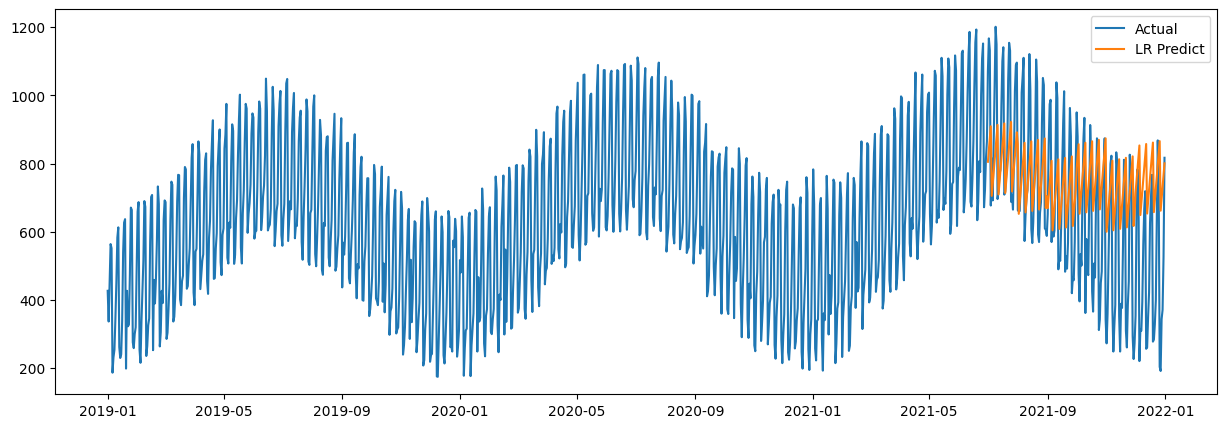

In [ ]:
plt.figure(figsize = (15,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
lr_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.lr_pred)
lr_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.lr_pred)
lr_r2_score = r2_score(y_true = test.item_count, y_pred = test.lr_pred)
print("Linear Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(lr_rmse,lr_mae,lr_r2_score*100))

Linear Regression :
RMSE : 59638.94
MAE : 196.04
R2_Score : 7.65


In [ ]:
results = pd.DataFrame([lr_rmse, lr_mae,lr_r2_score*100], index = ['RMSE', 'MAE', 'R2_Score'], columns = ['Linear Regression']).round(2)
results

,Linear Regression
RMSE,59638.94
MAE,196.04
R2_Score,7.65


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=20)
rf.fit(X_train, Y_train)

RandomForestRegressor(max_depth=20)

In [ ]:
test['rf_pred'] = rf.predict(X_test)

/tmp/ipykernel_11190/582745053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rf_pred'] = rf.predict(X_test)


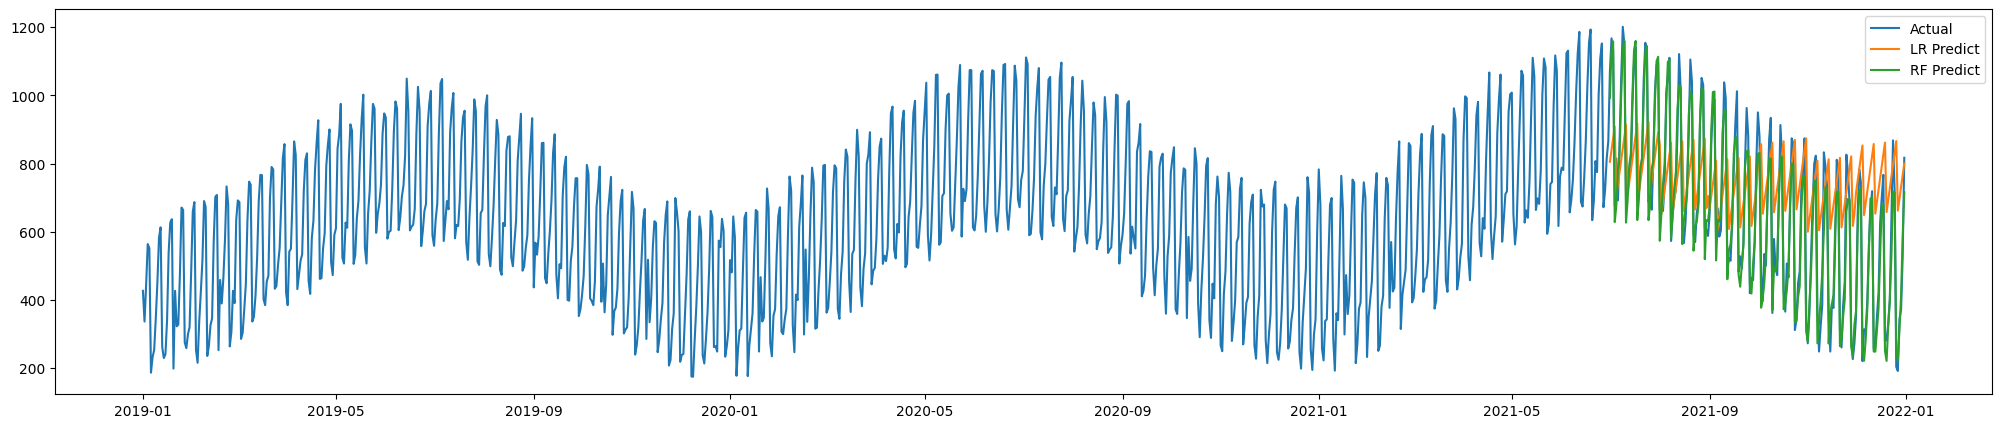

In [ ]:
plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.plot(test.rf_pred, label = "RF Predict")
plt.legend()
plt.show()

In [ ]:
rf_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.rf_pred)
rf_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.rf_pred)
rf_r2_score = r2_score(y_true = test.item_count, y_pred = test.rf_pred)
print("Random Forest Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(rf_rmse,rf_mae,rf_r2_score*100))

Random Forest Regression :
RMSE : 3482.99
MAE : 46.56
R2_Score : 94.61


In [ ]:
results['Random Forest'] = [rf_rmse,rf_mae,rf_r2_score*100]
results.round(2)

,Linear Regression,Random Forest
RMSE,59638.94,3482.99
MAE,196.04,46.56
R2_Score,7.65,94.61


In [5]:
import xgboost as xgb

## XGBoost

In [ ]:
xgb = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
xgb.fit(X_train, Y_train,
        eval_set=[(X_train, Y_train), (X_test, Y_test)],
        verbose=100)

[0]	validation_0-rmse:660.07829	validation_1-rmse:709.01212
[100]	validation_0-rmse:262.51190	validation_1-rmse:311.53220
[200]	validation_0-rmse:121.36888	validation_1-rmse:171.11193
[300]	validation_0-rmse:71.72975	validation_1-rmse:105.03640
[400]	validation_0-rmse:52.50055	validation_1-rmse:78.37923


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [08:13:48] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[500]	validation_0-rmse:44.19461	validation_1-rmse:71.59216
[591]	validation_0-rmse:40.35475	validation_1-rmse:72.11224


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

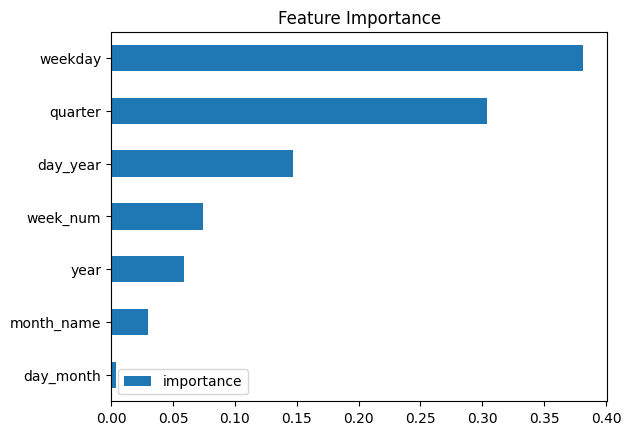

In [ ]:
importance = pd.DataFrame(data=xgb.feature_importances_,
             index=xgb.get_booster().feature_names,
             columns=['importance'])
importance.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

In [ ]:
test['xgb_pred'] = xgb.predict(X_test)

/tmp/ipykernel_11190/5488039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['xgb_pred'] = xgb.predict(X_test)


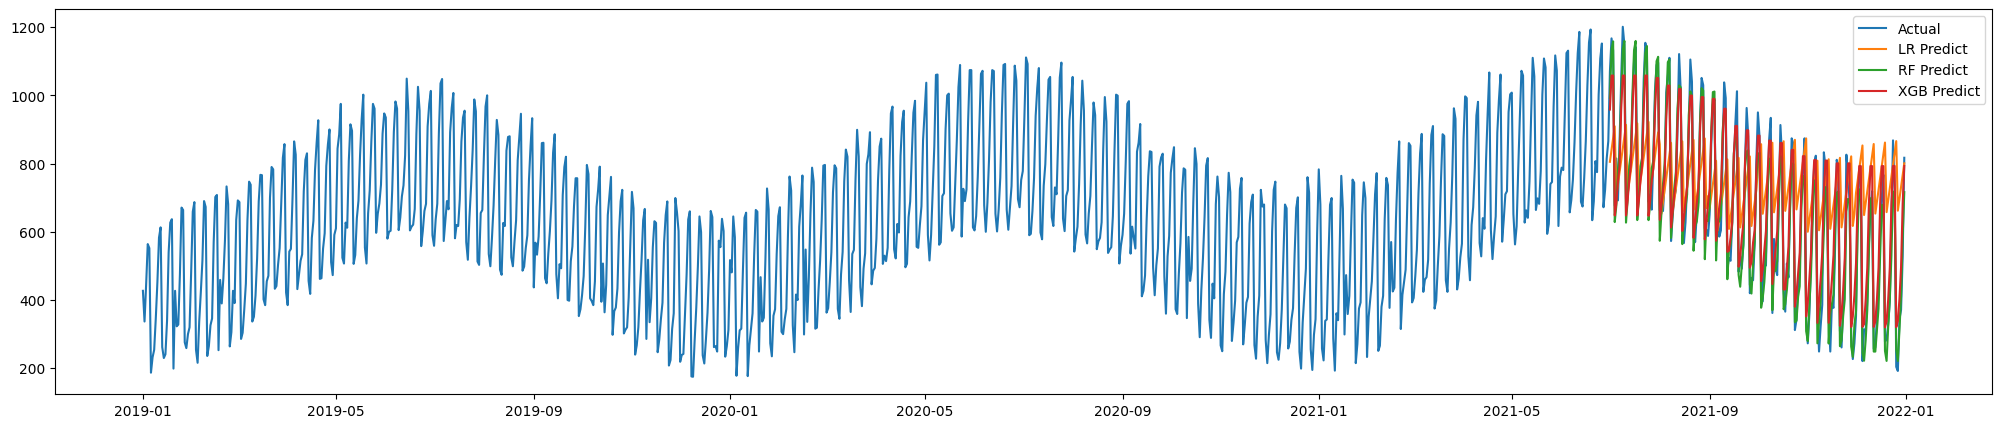

In [ ]:
plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(test.xgb_pred, label = "XGB Predict")
plt.legend()
plt.show()

In [ ]:
xgb_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.xgb_pred)
xgb_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.xgb_pred)
xgb_r2_score = r2_score(y_true = test.item_count, y_pred = test.xgb_pred)
print("XGBoost :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(xgb_rmse,xgb_mae,xgb_r2_score*100))

XGBoost :
RMSE : 5066.29
MAE : 58.45
R2_Score : 92.15


In [ ]:
results['XGBoost'] = [xgb_rmse,xgb_mae,xgb_r2_score*100]
results = results.round(2)

In [ ]:
results

,Linear Regression,Random Forest,XGBoost
RMSE,59638.94,3482.99,5066.29
MAE,196.04,46.56,58.45
R2_Score,7.65,94.61,92.15


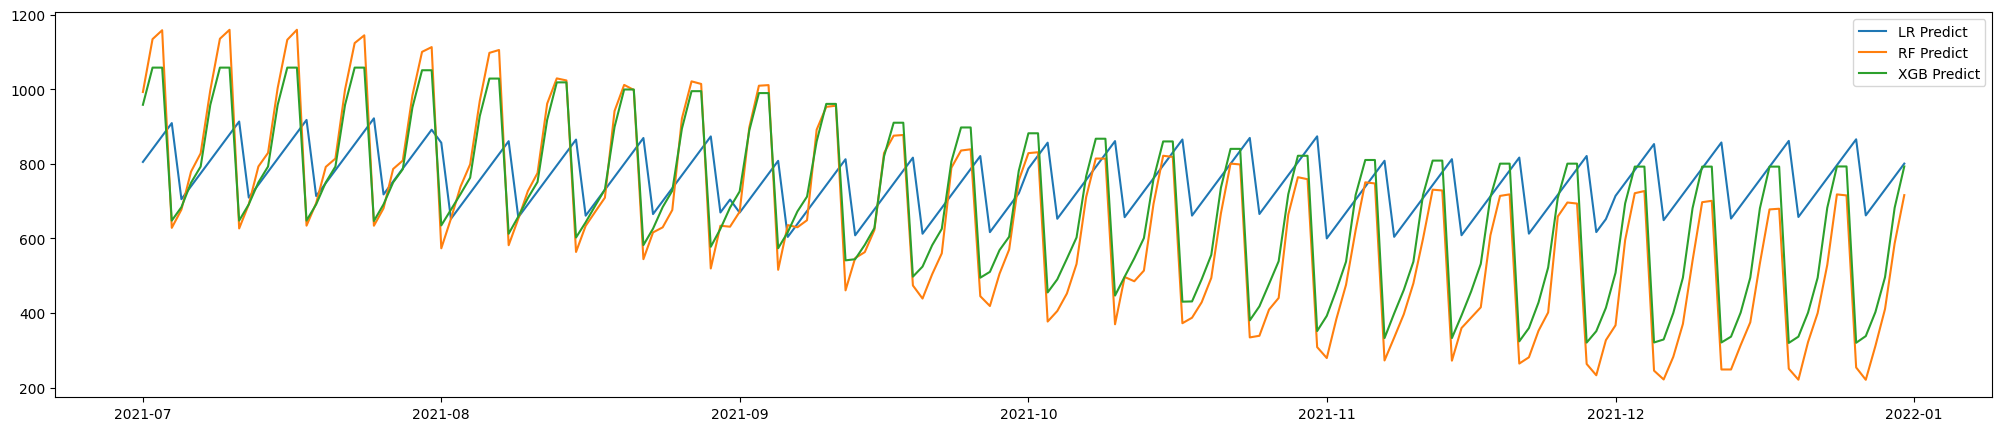

In [ ]:
plt.figure(figsize = (25,5))
plt.plot(test.lr_pred, label = "LR Predict")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(test.xgb_pred, label = "XGB Predict")
plt.legend()
plt.show()

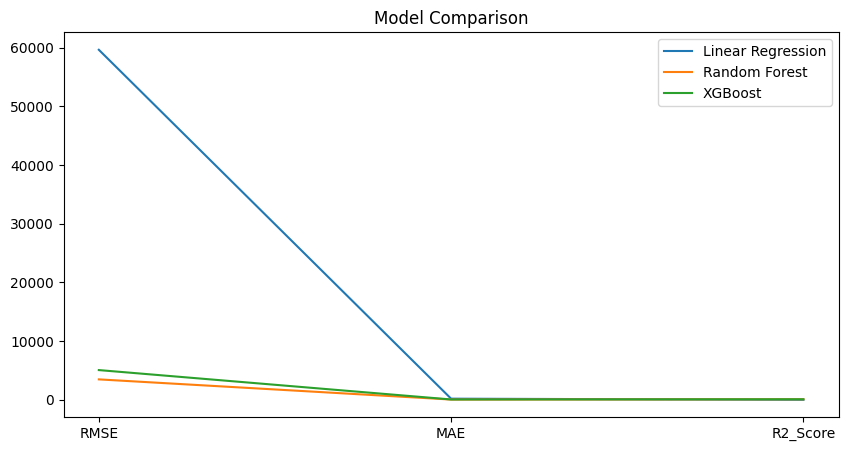

In [ ]:
plt.figure(figsize = (10,5))
plt.plot(results['Linear Regression'], label = "Linear Regression")
plt.plot(results['Random Forest'], label = "Random Forest")
plt.plot(results['XGBoost'], label = "XGBoost")
plt.legend(loc = "upper right")
plt.title("Model Comparison")
plt.show()


In [ ]:
results

,Linear Regression,Random Forest,XGBoost
RMSE,59638.94,3482.99,5066.29
MAE,196.04,46.56,58.45
R2_Score,7.65,94.61,92.15


## the best model here is RF : using it for predictions

In [ ]:
time_series.index.max()

Timestamp('2021-12-31 00:00:00')

In [ ]:
future_predictors = pd.DataFrame(pd.date_range(start="2022-01-01", end="2022-12-31"), columns=['date'])
future_predictors.index = pd.to_datetime(future_predictors.date)


In [ ]:
X_train.columns

Index(['weekday', 'quarter', 'year', 'month_name', 'day_year', 'day_month',
       'week_num'],
      dtype='object')

In [ ]:
future_predictors.date.dt.isocalendar().week

,week
date,
2022-01-01,52
2022-01-02,52
2022-01-03,1
2022-01-04,1
2022-01-05,1
...,...
2022-12-27,52
2022-12-28,52
2022-12-29,52


In [ ]:
future_predictors['weekday'] = future_predictors.date.dt.day_name()
future_predictors['quarter'] = future_predictors.date.dt.quarter
future_predictors['year'] = future_predictors.date.dt.year
future_predictors['month_name'] = future_predictors.date.dt.month_name()
future_predictors['day_year'] = future_predictors.date.dt.day_of_year
future_predictors['day_month'] = future_predictors.date.dt.day
future_predictors['week_num'] = future_predictors.date.dt.isocalendar().week


In [ ]:
future_predictors.head(2)

,date,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2022-01-01,2022-01-01,Saturday,1,2022,January,1,1,52
2022-01-02,2022-01-02,Sunday,1,2022,January,2,2,52


In [ ]:
future_predictors[['month_name', 'weekday']] = ord_enc.transform(future_predictors[['month_name', 'weekday']])

In [ ]:
future_predictors['predictions'] = rf.predict(future_predictors[X_train.columns])

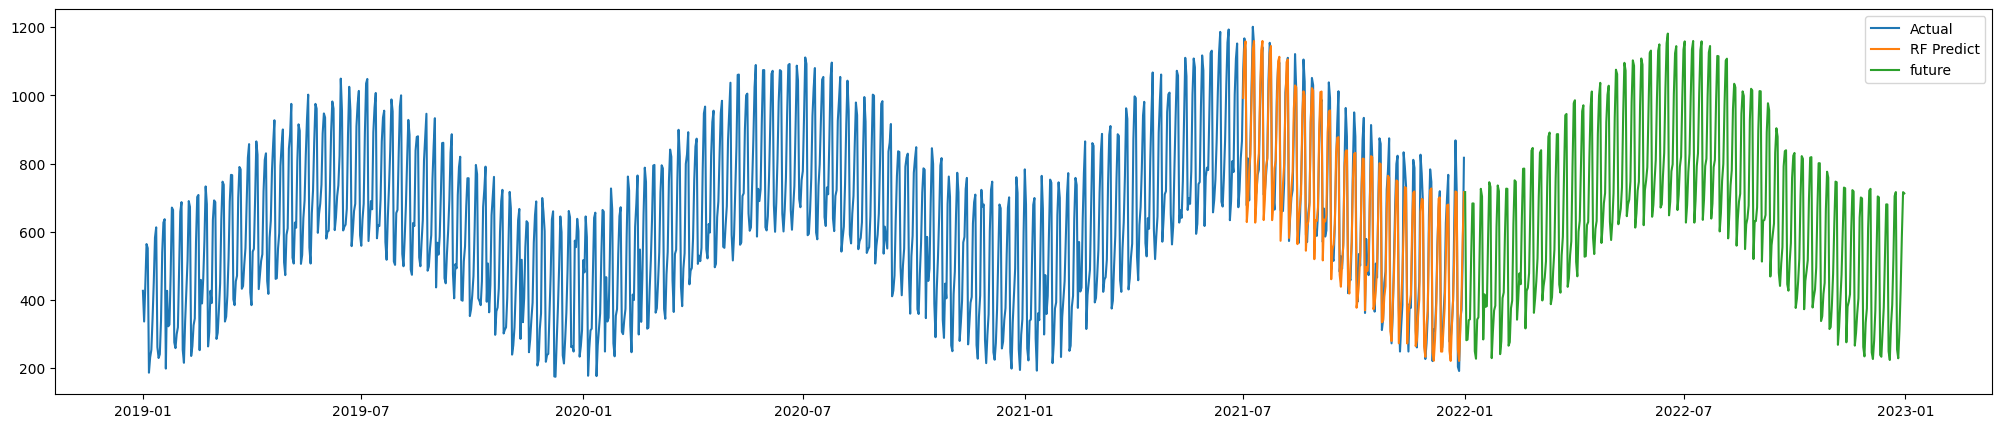

In [ ]:
plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(future_predictors.predictions, label = "future")
plt.legend()
plt.show()

Forecasting using deep learning algorithms:
Use sales amount for predictions instead of item count
Build a long short-term memory (LSTM) model for predictions
Define the train and test series
Generate synthetic data for the last 12 months
Build and train an LSTM model
Use the model to make predictions for the test data

Calculate the mean absolute percentage error (MAPE) and comment on the model's performance
Develop another model using the entire series for training, and use it to forecast for the next three months


# Forecasting using Deep Learning


In [ ]:
time_ser = data.groupby('date').agg({'sales_amnt': 'sum'})
time_ser

,sales_amnt
date,
2019-01-01,4023.00
2019-01-02,3074.69
2019-01-03,4062.71
2019-01-04,5006.81
2019-01-05,4927.53
...,...
2021-12-27,1867.71
2021-12-28,3426.50
2021-12-29,3715.39


## Define the train and test series

In [ ]:
train = time_ser[time_ser.index < '2021-07-01']
test = time_ser[time_ser.index >= '2021-07-01']

## data scaling

In [ ]:
scaler = MinMaxScaler()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

## Generate synthetic data

In [ ]:
# We're only using one feature here
n_features = 1
length = 12

In [ ]:
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=1)

## Build and train LSTM Model

In [ ]:
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(length, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stop = EarlyStopping(monitor='val_loss',patience=10)

In [ ]:
validation_generator = TimeseriesGenerator(scaled_test,scaled_test, length=length, batch_size=1)

## fit model

In [ ]:
model.fit(generator,epochs=20,
                    validation_data=validation_generator,
                   callbacks=[early_stop])

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0307 - val_loss: 0.0195
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0124 - val_loss: 0.0162
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0103 - val_loss: 0.0121
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0094 - val_loss: 0.0097
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0084 - val_loss: 0.0076
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0081 - val_loss: 0.0073
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0070 - val_loss: 0.0073
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0070 - val_loss: 0.0086
Epoch 9/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0064 - val_loss: 0.0068
Epoch 10/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 11/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0052 - val_loss: 0.0046
Epoch 12/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8

<Axes: >

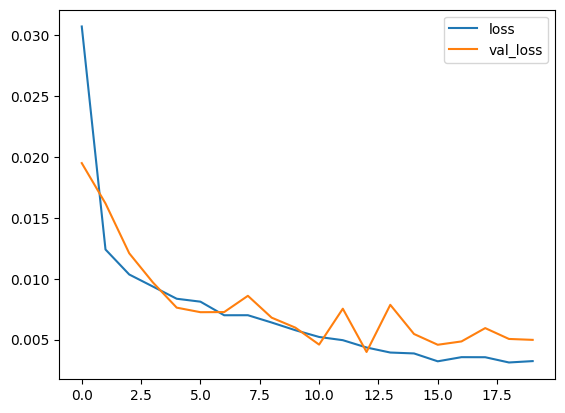

In [ ]:
losses = pd.DataFrame(model.history.history)
losses.plot()

## Evaluate

In [ ]:
test_predictions = []
first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))
for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    # store prediction
    test_predictions.append(current_pred)
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━

# Make predictions

In [ ]:
true_predictions = scaler.inverse_transform(test_predictions)

In [ ]:
test['Predictions'] = true_predictions

/tmp/ipykernel_11190/4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


In [ ]:
test

,sales_amnt,Predictions
date,,
2021-07-01,10290.33,9614.913130
2021-07-02,11028.59,10599.634152
2021-07-03,10793.51,10903.918833
2021-07-04,6524.13,7059.558538
2021-07-05,7983.57,6709.399077
...,...,...
2021-12-27,1867.71,5129.565974
2021-12-28,3426.50,5818.040265
2021-12-29,3715.39,6351.121033


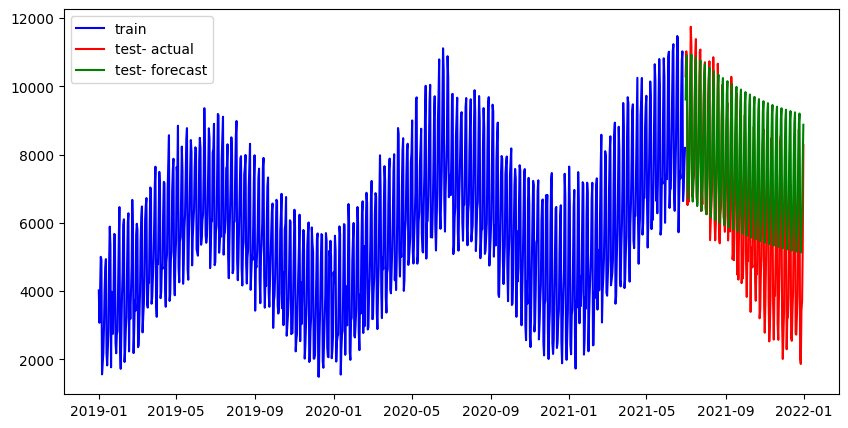

In [ ]:
plt.figure(figsize = (10,5))
plt.plot(train, color = 'blue', label = 'train')
plt.plot(test.sales_amnt, color = 'red', label = 'test- actual')
plt.plot(test.index, test.Predictions,color = 'green', label = 'test- forecast')
plt.legend()
plt.show()

test.plot(figsize=(12,8))

## Calculate MAPE

In [ ]:
mape_dl = mean_absolute_percentage_error(y_true = test.sales_amnt, y_pred = test.Predictions)
print("MAPE for LSTM : ", mape_dl)

MAPE for LSTM :  0.310114771495922


In [ ]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(time_ser)

In [ ]:
length = 3*30 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(scaled_full_data, scaled_full_data, length=length, batch_size=1)

In [ ]:
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(length, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(generator,epochs=8)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 49s 43ms/step - loss: 0.0375
Epoch 2/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - loss: 251.7574
Epoch 3/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - loss: 0.0307
Epoch 4/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - loss: 0.0302
Epoch 5/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step - loss: 0.0288
Epoch 6/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - loss: 0.0269
Epoch 7/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - loss: 0.0143
Epoch 8/8
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - loss: 0.0105


In [ ]:
forecast = []
periods = 3*30

first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(periods):

    # get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]

    # store prediction
    forecast.append(current_pred)

    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━

In [ ]:
forecast = scaler.inverse_transform(forecast)

In [ ]:
forecast_dates = pd.date_range(start='2022-01-01 ',periods=3*30, freq = "D")

In [ ]:
forecast_data = pd.DataFrame(data=forecast,index=forecast_dates,
                           columns=['Forecast']).squeeze()

In [ ]:
forecast_data

,Forecast
2022-01-01,5931.269882
2022-01-02,3910.503230
2022-01-03,2588.812245
2022-01-04,3020.943621
2022-01-05,4267.892383
...,...
2022-03-27,4504.706188
2022-03-28,5595.928931
2022-03-29,5999.814270
2022-03-30,5336.818630


In [ ]:
time_ser

,sales_amnt
date,
2019-01-01,4023.00
2019-01-02,3074.69
2019-01-03,4062.71
2019-01-04,5006.81
2019-01-05,4927.53
...,...
2021-12-27,1867.71
2021-12-28,3426.50
2021-12-29,3715.39


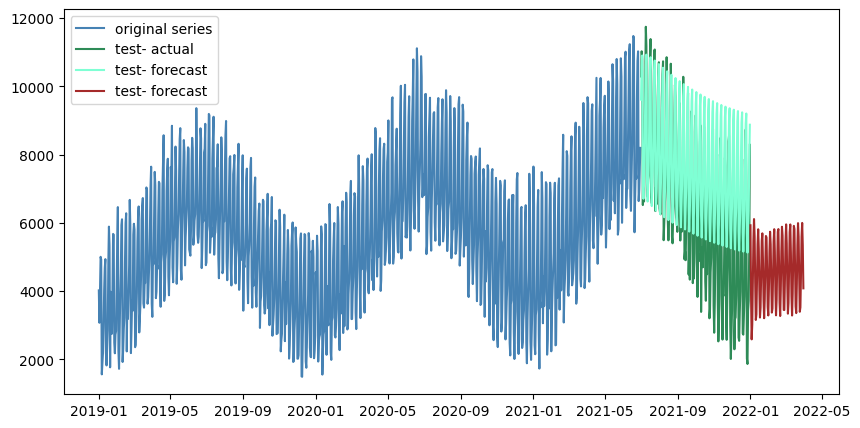

In [ ]:
plt.figure(figsize = (10,5))
plt.plot(train.index, train.sales_amnt, color = 'steelblue', label = 'original series')
plt.plot(test.index, test.sales_amnt,color = 'seagreen', label = 'test- actual')
plt.plot(test.index, test.Predictions,color = 'aquamarine', label = 'test- forecast')
plt.plot(forecast_data.index, forecast_data.values, color = 'brown', label = 'test- forecast')
plt.legend()
plt.show()

In [ ]:

mape_dl

0.310114771495922

In [ ]:

pd.DataFrame([mape_dl ], index = ['LSTM'])

,0
LSTM,0.310115
